In [57]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import xarray as xr
import matplotlib.gridspec as gs

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [58]:
plt.rcParams.update({
    "text.usetex": False,
    "text.latex.preamble":r'\usepackage{sansmathfonts}\usepackage{helvet}\usepackage{amsmath}\usepackage{amssymb}\usepackage{nicefrac}', 
    "axes.linewidth":2, 
    "axes.titlepad":15, 
    "axes.labelpad":8,
    "axes.labelsize":16.5,
    "axes.titlesize":17.5,
    "xtick.major.width":2, 
    "xtick.minor.width":2, 
    "xtick.major.size":7, 
    "xtick.minor.size":5,
    "ytick.major.width":2, 
    "ytick.minor.width":2, 
    "ytick.major.size":7, 
    "ytick.minor.size":5,
    "ytick.right":True, 
    "xtick.top":True,
    "xtick.major.pad":7,
    "xtick.minor.pad":7,
    "ytick.major.pad":5,
    "ytick.minor.pad":5,
    "xtick.labelsize":18, 
    "ytick.labelsize":18,
    "xtick.direction":'in',
    "ytick.direction":'in',
    "axes.grid":True,
    "grid.alpha":0.5,
    "grid.color":'gray',
    "grid.linestyle":':',
    "grid.linewidth":1.5,
    "lines.linewidth":3,
    "legend.fontsize":12.5,
    "contour.negative_linestyle":'dashed'
    })


In [59]:
def Plot(rad, the, z, lo_lim, up_lim, title, f_name, c_bar_label = " "):
    """Function for plotting the xarray data.
    rad: radius data.
    the: theta data.
    z: the data relating to the value at each point.
    lo_lim: lower limit for the colour map.
    up_lim: upper limimt of the colour map.
    c_bar_label: label for the colour bar.
    title: title fot the plot."""
    grid = gs.GridSpec(1,3, wspace=0.2, hspace=0.18, bottom=0.05, top=0.975, left=0.025, right=0.85, width_ratios=[1,0,0.1])
    fig = plt.figure(figsize=(7,5))



    def e_to_10_fn(s1): 
        return s1.split('e')[0]+r'$\times10^{%s}$'%s1.split('e')[1]

    cmap = plt.cm.RdBu_r
    levels = np.linspace(lo_lim, up_lim, 51)
    norm = mpl.colors.BoundaryNorm(levels, cmap.N, extend='both')

    smap = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)


    sintheta = np.sin(the)
    costheta = np.cos(the)
    x = sintheta * rad/5 
    y = costheta * rad/5
            
    ax = fig.add_subplot(grid[0])        
    #ax.set_xlim([-.005,1.1])
    #ax.set_ylim([-.005,1.1])
    ax.set_aspect('equal', adjustable='box')        
    ax.plot(x[:,0], y[:,0],'k', lw=2)
    ax.plot(x[:,-1], y[:,-1],'k', lw=2)
    ax.plot(x[:,-1]*5/5.2, y[:,-1]*5/5.2,'k', lw=1, ls='--')
    ax.plot(x[:,-1]*4/5.2, y[:,-1]*4/5.2,'k', lw=1, ls='--')
    ax.plot([0,0],[y[-1,0],y[-1,-1]], 'k', lw=2)
    ax.plot([3.8/5,5.2/5],[0,0], 'k', lw=2)
    #ax.text(0.,0.14,r'Ra$_{\text{F}}$ = '+e_to_10_fn('3e8'), ha='left', fontsize=20)#, pad=-50)
    #ax.text(0.,0.02,r'Ta   \ \ \kern1pt= '+e_to_10_fn('1e5'), ha='left', fontsize=20)#, pad=-50)
    #ax.axis('off')
    ax.contourf(x, y, z, levels=levels, cmap=cmap, norm=norm, extend='both')
    ax.set_title(title)




    cgrid = gs.GridSpecFromSubplotSpec(8,1, subplot_spec=grid[0, -1])
    cax = fig.add_subplot(cgrid[:]) 
    cbar=plt.colorbar(smap, cax=cax, orientation='vertical')
    cbar.ax.yaxis.minorticks_off()
    #cbar.set_label(c_bar_label)

    plt.savefig(f'/home/bs583/analysis_notebooks/zonal_velocity_plots/zonal_{f_name}.jpg', dpi=1000, bbox_inches='tight')
                

In [60]:
ds = xr.open_dataset('/data/ntl203/data_for_ben/phi_avgs_timavg_Raf9.5e8_Ta1e7.nc')
ds

<xarray.Dataset> Size: 80MB
Dimensions:                    (theta: 768, r: 240)
Coordinates:
  * theta                      (theta) float64 6kB 3.138 3.134 ... 0.003129
  * r                          (r) float64 2kB 3.8 3.8 3.8 3.801 ... 5.2 5.2 5.2
Data variables: (12/54)
    L_zonal_phi_avg            (theta, r) float64 1MB ...
    ang_vel_zonal_phi_avg      (theta, r) float64 1MB ...
    b_phi_avg                  (theta, r) float64 1MB ...
    bpbp_phi_avg               (theta, r) float64 1MB ...
    bppp_phi_avg               (theta, r) float64 1MB ...
    coriolis_mom               (theta, r) float64 1MB ...
    ...                         ...
    vpvp_phi_avg               (theta, r) float64 1MB ...
    vpwp_phi_avg               (theta, r) float64 1MB ...
    w_phi_avg                  (theta, r) float64 1MB ...
    wpbp_phi_avg               (theta, r) float64 1MB ...
    wppp_phi_avg               (theta, r) float64 1MB ...
    wpwp_phi_avg               (theta, r) float64 1MB ...

duu_dr: $ \frac{\partial\overline{u_u}}{\partial r} $  
duu_dtheta: $ \frac{\partial\overline{u_u}}{\partial\theta} $  
druuuw_dr: $ \frac{\partial }{\partial r} (r^2 {u_u}'{u_w}') $  
dsinuuuv_dtheta: $ \frac{\partial }{\partial \theta} (\sin(\theta) {u_u}' {u_v}') $  
druu_dr_sqr: $ \frac{\partial^2}{\partial r^2} (r \overline{u}) $  
duu_dtheta_sqr: $ \frac{\partial^2 \overline{u_u}}{\partial \theta^2} $

In [61]:
u_phi_av = ds.u_phi_avg.sel(theta = slice(np.pi,0))
v_phi_av = ds.v_phi_avg.sel(theta = slice(np.pi,0))
w_phi_av = ds.w_phi_avg.sel(theta = slice(np.pi,0))

upwp = ds.upwp_phi_avg.sel(theta = slice(np.pi,0))
upvp = ds.upvp_phi_avg.sel(theta = slice(np.pi,0))

r = u_phi_av.r
theta = u_phi_av.theta

duu_dr = u_phi_av.differentiate("r")
duu_dtheta = u_phi_av.differentiate("theta")

druuuw_dr = ( upwp*r**2).differentiate("r")
dsinuuuv_dtheta = (upvp*np.sin(theta)).differentiate("theta")
druu_dr_sqr = (duu_dr*r).differentiate("r")
duu_dtheta_sqr = duu_dtheta.differentiate("theta")

In [62]:
print(f"duu_dr {duu_dr.shape}")
print(f"druu_dr_sqr {druu_dr_sqr.shape}")
print(f"r {r.shape}")

duu_dr (768, 240)
druu_dr_sqr (768, 240)
r (240,)


In [63]:
pr = 1
raf = 9.5e8
ta = 1e7

pr_raf = np.sqrt(pr/raf)
ta_pr_raf = np.sqrt(ta*pr/raf)
print(f"pr_raf {pr_raf}")
print(f"ta_pr_raf {ta_pr_raf}")

pr_raf 3.2444284226152505e-05
ta_pr_raf 0.10259783520851541


In [64]:

t2 = w_phi_av * duu_dr
t3 = (v_phi_av * duu_dtheta)/r
t4 = druuuw_dr / r
t5 = dsinuuuv_dtheta / (r * np.sin(theta))
t6 = ta_pr_raf* w_phi_av *np.sin(theta)

t7 = pr_raf * druu_dr_sqr / r
t8 = pr_raf * duu_dtheta_sqr /(r**2)
t9 = pr_raf * duu_dtheta /(np.tan(theta) * r**2 )
t12 = -pr_raf * u_phi_av / (r**2 *np.sin(theta))

LHS: t2+t3+t4+t5+t6  
RHS: t7+t8+t9+t12  

In [65]:
print(f"t2 {t2.shape}")
print(f"t3 {t3.shape}")
print(f"t4 {t4.shape}")
print(f"t5 {t5.shape}")
print(f"t6 {t6.shape}")
print(f"t7 {t7.shape}")
print(f"t8 {t8.shape}")
print(f"t9 {t9.shape}")
print(f"t12 {t12.shape}")

t2 (768, 240)
t3 (768, 240)
t4 (768, 240)
t5 (768, 240)
t6 (768, 240)
t7 (768, 240)
t8 (768, 240)
t9 (768, 240)
t12 (768, 240)


In [78]:
LHS = t2+t3+t4+t5+t6

RHS = t7+t8+t9+t12

print(f"LHS {type(LHS)}, RHS {type(RHS)}")
tot = RHS-LHS
print(f"tot {type(tot)}")
print(tot)
#tot = tot.transpose()
#file_name = "balenced_eqn_non_dim"
#plot_title = "balenced eqn non dim"

LHS <class 'xarray.core.dataarray.DataArray'>, RHS <class 'xarray.core.dataarray.DataArray'>
tot <class 'xarray.core.dataarray.DataArray'>
<xarray.DataArray (theta: 768, r: 240)> Size: 1MB
array([[-2.30242818e-04, -2.49925630e-04, -3.40203274e-04, ...,
         8.42996391e-04,  9.32394863e-04,  9.60904053e-04],
       [ 1.00309260e-03,  9.94247171e-04,  9.30930449e-04, ...,
         1.76126966e-03,  1.85880476e-03,  1.89939347e-03],
       [ 1.88501501e-03,  1.88876715e-03,  1.81225066e-03, ...,
         1.60514428e-03,  1.72320231e-03,  1.75495312e-03],
       ...,
       [ 6.20691101e-04,  7.76489352e-04,  1.13525094e-03, ...,
         2.60972372e-03,  2.34230749e-03,  2.23982444e-03],
       [ 6.84001516e-04,  7.71378021e-04,  1.01172575e-03, ...,
         2.31418612e-03,  2.22126850e-03,  2.22215696e-03],
       [-1.02381515e-05, -8.08534188e-05, -2.13031031e-04, ...,
        -2.00913960e-04, -3.01859470e-04, -3.69254670e-04]],
      shape=(768, 240))
Coordinates:
  * theta    (the

In [79]:
#r'$\frac{\partial \overline{u_\varphi}}{\partial t}$'
#r'$\frac{\partial \overline{u_\varphi}}{\partial t}$'

In [88]:
advec = t2+t3+t4+t5
#plot_title = "advection terms"
#file_name = "advection_terms"
advec

<xarray.DataArray (theta: 768, r: 240)> Size: 1MB
array([[ 0.00042781,  0.00043791,  0.00045282, ..., -0.00075494,
        -0.00078364, -0.000802  ],
       [-0.00088499, -0.00088463, -0.00088205, ..., -0.00171464,
        -0.00176663, -0.00180081],
       [-0.00167813, -0.00169537, -0.0017215 , ..., -0.00152225,
        -0.00155623, -0.00157969],
       ...,
       [-0.00086264, -0.00100963, -0.00124614, ..., -0.00268497,
        -0.00254473, -0.00245754],
       [-0.00090885, -0.00098775, -0.001115  , ..., -0.00237158,
        -0.00239635, -0.00241255],
       [ 0.00012422,  0.00019033,  0.0003022 , ...,  0.00022134,
         0.00033031,  0.00039903]], shape=(768, 240))
Coordinates:
  * theta    (theta) float64 6kB 3.138 3.134 3.13 ... 0.01126 0.007183 0.003129
  * r        (r) float64 2kB 3.8 3.8 3.8 3.801 3.801 ... 5.199 5.199 5.2 5.2 5.2

In [89]:
cori = t6
plot_title = "coriolis term with non dim"
file_name = "coriolis_term_non_dim"
cori

<xarray.DataArray (theta: 768, r: 240)> Size: 1MB
array([[ 1.34274665e-10,  1.32385679e-09,  3.90929826e-09, ...,
        -6.33747340e-09, -2.35154491e-09, -2.71854448e-10],
       [ 3.78154416e-10,  3.41773000e-09,  9.51978941e-09, ...,
        -1.14239502e-08, -4.12210846e-09, -4.59389543e-10],
       [ 6.11859556e-10,  5.36052822e-09,  1.45950110e-08, ...,
        -1.27264726e-08, -4.49342355e-09, -4.85964365e-10],
       ...,
       [ 8.64633579e-10,  7.79283903e-09,  2.16689651e-08, ...,
         1.91207082e-08,  6.87626008e-09,  7.62840400e-10],
       [ 5.90030648e-10,  5.35115931e-09,  1.49460783e-08, ...,
         1.35841620e-08,  4.86415734e-09,  5.36406009e-10],
       [ 3.01819862e-10,  2.70173255e-09,  7.47527941e-09, ...,
         5.64244689e-09,  2.04008315e-09,  2.27968712e-10]],
      shape=(768, 240))
Coordinates:
  * theta    (theta) float64 6kB 3.138 3.134 3.13 ... 0.01126 0.007183 0.003129
  * r        (r) float64 2kB 3.8 3.8 3.8 3.801 3.801 ... 5.199 5.199 5.2 5.2 5.2

In [90]:
difus = t7+t8+t9+t12
#plot_title = "diffusive terms with non dim"
#file_name = "diffusive_terms_non_dim"
difus

<xarray.DataArray (theta: 768, r: 240)> Size: 1MB
array([[ 1.97572297e-04,  1.87980831e-04,  1.12617737e-04, ...,
         8.80513947e-05,  1.48749232e-04,  1.58907911e-04],
       [ 1.18102772e-04,  1.09616018e-04,  4.88863917e-05, ...,
         4.66155324e-05,  9.21737520e-05,  9.85843314e-05],
       [ 2.06885850e-04,  1.93397997e-04,  9.07655304e-05, ...,
         8.28823945e-05,  1.66963039e-04,  1.75263555e-04],
       ...,
       [-2.41944387e-04, -2.33132862e-04, -1.10872133e-04, ...,
        -7.52299960e-05, -2.02417533e-04, -2.17716749e-04],
       [-2.24845327e-04, -2.16367285e-04, -1.03263413e-04, ...,
        -5.73783181e-05, -1.75074782e-04, -1.90392676e-04],
       [ 1.13980071e-04,  1.09480387e-04,  8.91803158e-05, ...,
         2.04269958e-05,  2.84513190e-05,  2.97748526e-05]],
      shape=(768, 240))
Coordinates:
  * theta    (theta) float64 6kB 3.138 3.134 3.13 ... 0.01126 0.007183 0.003129
  * r        (r) float64 2kB 3.8 3.8 3.8 3.801 3.801 ... 5.199 5.199 5.2 5.2 5.2

In [91]:
print(r)

<xarray.DataArray 'r' (r: 240)> Size: 2kB
array([3.800015, 3.800135, 3.800375, ..., 5.199625, 5.199865, 5.199985],
      shape=(240,))
Coordinates:
  * r        (r) float64 2kB 3.8 3.8 3.8 3.801 3.801 ... 5.199 5.199 5.2 5.2 5.2


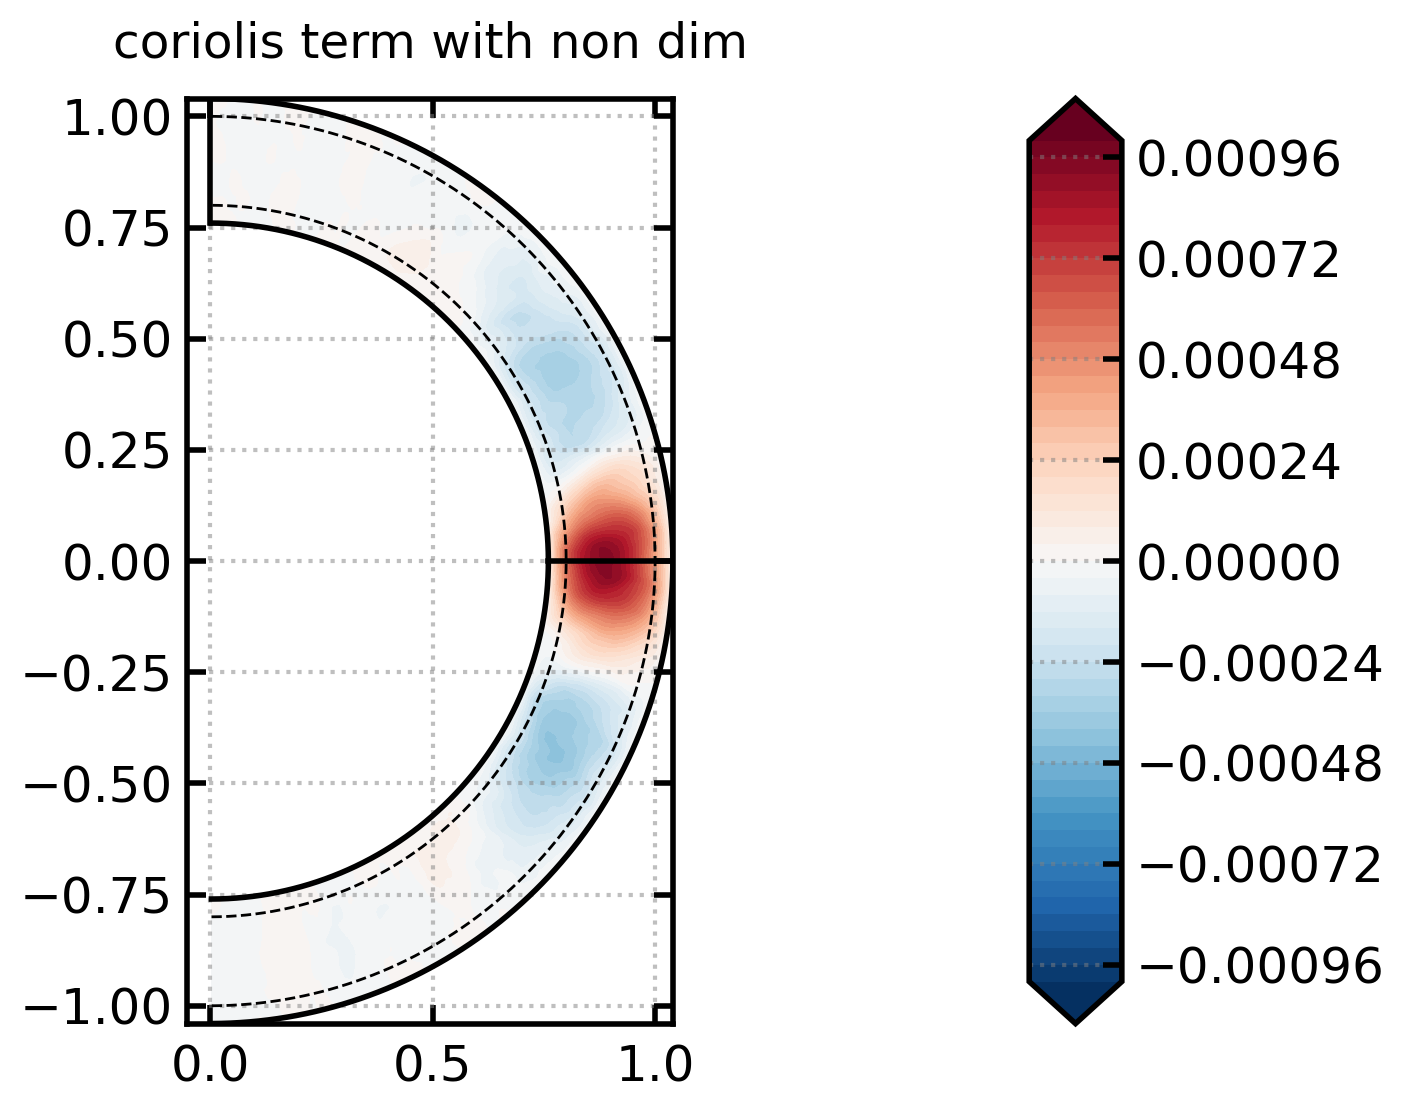

In [92]:
Plot(rad = r, the = theta, z = cori, lo_lim = -0.001, up_lim = 0.001, title = plot_title, f_name = file_name )

grid = gs.GridSpec(1,3, wspace=0.2, hspace=0.18, bottom=0.05, top=0.975, left=0.025, right=0.85, width_ratios=[1,0,0.1])
fig = plt.figure(figsize=(7,5))



def e_to_10_fn(s1): 
    return s1.split('e')[0]+r'$\times10^{%s}$'%s1.split('e')[1]

cmap = plt.cm.RdBu_r
levels = np.linspace(-0.001, 0.001, 51)
norm = mpl.colors.BoundaryNorm(levels, cmap.N, extend='both')

smap = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)


sintheta = np.sin(theta)
costheta = np.cos(theta)
x = sintheta * r/5 
y = costheta * r/5
        
ax = fig.add_subplot(grid[0])        
#ax.set_xlim([-.005,1.1])
#ax.set_ylim([-.005,1.1])
ax.set_aspect('equal', adjustable='box')        
ax.plot(x[:,0], y[:,0],'k', lw=2)
ax.plot(x[:,-1], y[:,-1],'k', lw=2)
ax.plot(x[:,-1]*5/5.2, y[:,-1]*5/5.2,'k', lw=1, ls='--')
ax.plot(x[:,-1]*4/5.2, y[:,-1]*4/5.2,'k', lw=1, ls='--')
ax.plot([0,0],[y[-1,0],y[-1,-1]], 'k', lw=2)
ax.plot([3.8/5,5.2/5],[0,0], 'k', lw=2)
#ax.text(0.,0.14,r'Ra$_{\text{F}}$ = '+e_to_10_fn('3e8'), ha='left', fontsize=20)#, pad=-50)
#ax.text(0.,0.02,r'Ta   \ \ \kern1pt= '+e_to_10_fn('1e5'), ha='left', fontsize=20)#, pad=-50)
#ax.axis('off')
ax.contourf(x, y, t4+t5, levels=levels, cmap=cmap, norm=norm, extend='both')
#ax.set_title(r'$\frac{\partial \overline{u_\varphi}}{\partial t}$')




cgrid = gs.GridSpecFromSubplotSpec(8,1, subplot_spec=grid[0, -1])
cax = fig.add_subplot(cgrid[:]) 
cbar=plt.colorbar(smap, cax=cax, orientation='vertical')
cbar.ax.yaxis.minorticks_off()
#cbar.set_label(r'$\frac{\partial \overline{u_\varphi}}{\partial t}$')

#plt.savefig('av_zonal_velocity.png', dpi=500)
            